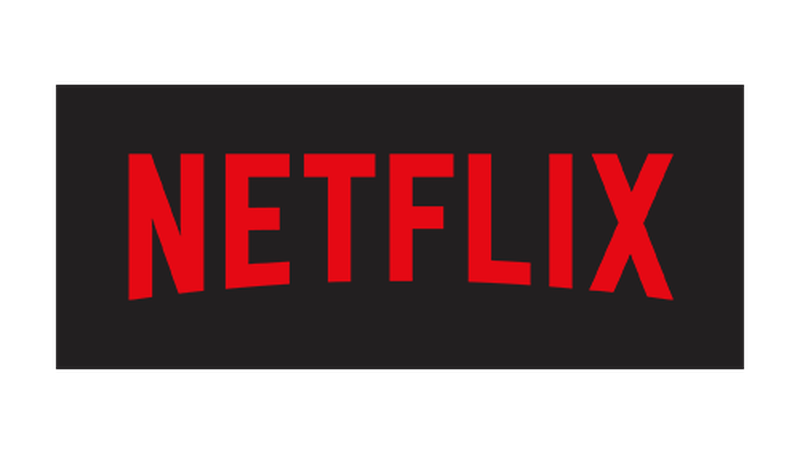

In [330]:
from IPython.display import Image, display
display(Image(filename="netflix_logo.png"))

# Netflix Data Science Project:

## Introduction
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on a Netflix dataset. The goal is to uncover trends in content creation, understand distribution across countries, and categorize content for better insights.

### Steps covered:
1. **Data Cleaning:** Handling missing values and duplicates.
2. **Feature Engineering:** Creating new metrics like `year_added`, `cast_count`, and `rating_category`.
3. **Exploratory Analysis:** Statistical summaries and visual inspections.

## 1. Environment Setup and Data Loading
In this section, we import the necessary libraries for data manipulation (`pandas`, `numpy`) and visualization (`seaborn`, `matplotlib`). We also load the raw Netflix dataset.

In [331]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from warnings import filterwarnings
filterwarnings("ignore")



df = pd.read_csv("dataset/Netflix.csv")

## 2. Initial Data Inspection
Before cleaning, we take a quick look at the first few rows of the data, its dimensions, and the data types of each column to identify potential issues.

In [332]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [333]:
df.shape

(7787, 12)

In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [335]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [336]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [337]:
df.duplicated().sum()

np.int64(0)

## 3. Data Cleaning
To ensure the quality of our analysis, we perform the following:
* **Drop Unnecessary Columns:** Removing `show_id` as it serves only as a unique identifier.
* **Impute Missing Values:** Filling gaps in `director`, `cast`, and `country` with "Unknown", and using the mode for `rating` and `date_added`.

In [338]:
df.drop(columns=['show_id'], inplace=True)

In [339]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

## 4. Feature Engineering
We create new features to extract more value from the existing data:
1. **Date Extraction:** Converting `date_added` to datetime objects to extract year and month.
2. **Complexity Metrics:** Calculating the number of cast members and genres per title.
3. **Categorization:** Simplifying the content ratings into broader categories: **Adult**, **Teen**, and **Kids**.
4. **Localization:** Extracting the primary country of origin from the `country` column.

In [340]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [341]:
df.drop(columns=['date_added'], inplace=True)

In [342]:
df['cast_count'] = df['cast'].apply(lambda x: len(x.split(',')))
df['genre_count'] = df['genres'].apply(lambda x: len(x.split(',')))

In [343]:
df['duration_type'] = df['type']

df.rename(columns={'duration':'duration_value'}, inplace=True)

In [344]:
df['country_main'] = df['country'].apply(lambda x: x.split(',')[0])

In [345]:
def simplify_rating(r):
    if r in ['TV-MA','R','NC-17']:
        return "Adult"
    elif r in ['PG-13','TV-14']:
        return "Teen"
    else:
        return "Kids"

df['rating_category'] = df['rating'].apply(simplify_rating)

In [346]:
df.drop(columns=['rating'], inplace=True)

## 5. Exploratory Data Analysis & Visualization
With the data cleaned and enriched, we now move to the visualization phase. This help us identify:
* The distribution of content types (Movies vs. TV Shows).
* Trends in content releases over the years.
* Relationship between content duration and its category.

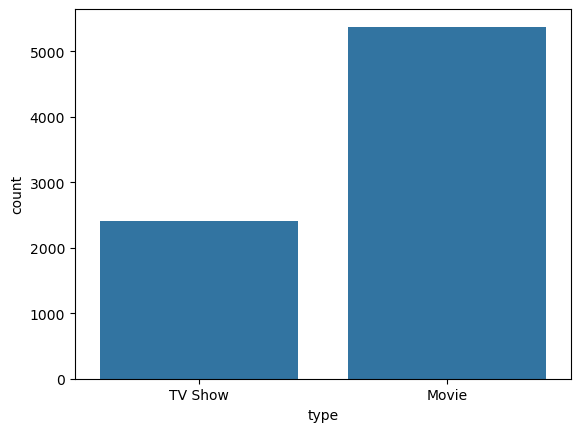

In [347]:
sns.countplot(x="type",data=df)
plt.show()

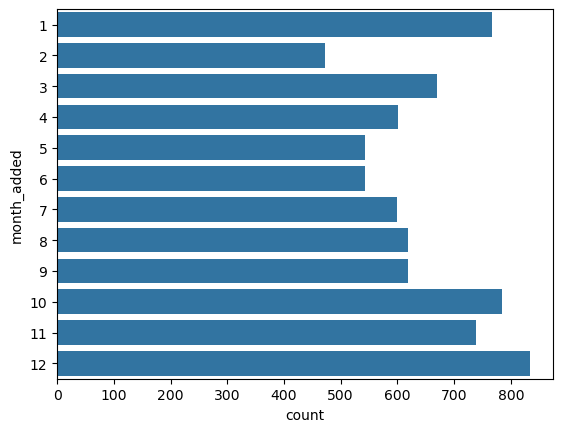

In [348]:
sns.countplot(y="month_added",data=df)
plt.show()

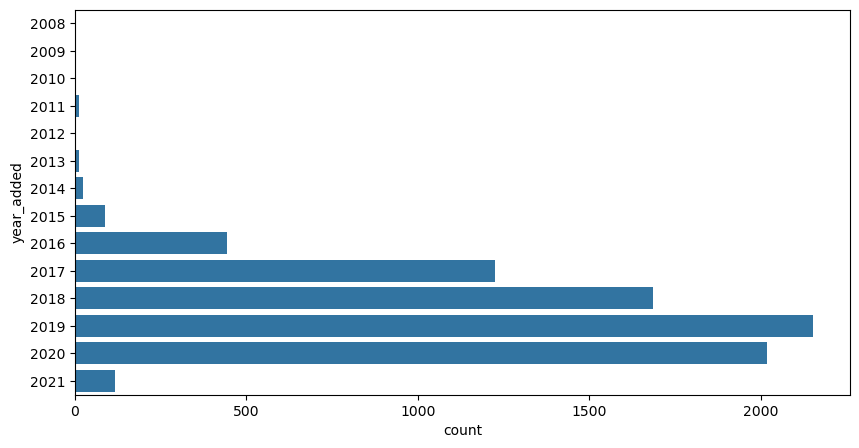

In [349]:
plt.figure(figsize=(10,5))
sns.countplot(y=df["year_added"])
plt.show()

In [350]:
df['has_director'] = df['director'].apply(lambda x: 0 if x=='Unknown' else 1)

In [351]:
df.corr(numeric_only=True)

,release_year,duration_value,year_added,month_added,cast_count,genre_count,has_director
release_year,1.000000,-0.240836,0.100115,-0.009661,-0.086585,-0.052931,-0.166603
duration_value,-0.240836,1.000000,0.037102,-0.024913,0.096601,0.092256,0.820335
year_added,0.100115,0.037102,1.000000,-0.135006,0.113470,0.060552,-0.001745
month_added,-0.009661,-0.024913,-0.135006,1.000000,0.001902,-0.002332,-0.028360
cast_count,-0.086585,0.096601,0.113470,0.001902,1.000000,0.219182,0.008707
genre_count,-0.052931,0.092256,0.060552,-0.002332,0.219182,1.000000,-0.041000
has_director,-0.166603,0.820335,-0.001745,-0.028360,0.008707,-0.041000,1.000000


<Axes: >

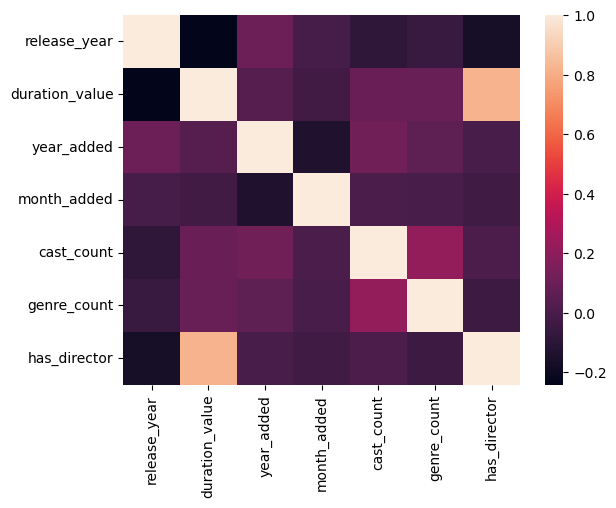

In [352]:
sns.heatmap(df.corr(numeric_only=True))

## Q1] CONTENT-TYPE LABELER:

In [353]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,month_added,cast_count,genre_count,duration_type,country_main,rating_category,has_director
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,11,3,TV Show,Brazil,Adult,0
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,8,3,Movie,India,Adult,1
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,4,3,Movie,Indonesia,Kids,1
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,11,1,Movie,United States,Adult,1
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,12,1,3,TV Show,United Kingdom,Kids,0


### LOGISTIC - REGRESSION:

In [354]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle


num_features = ['cast_count', 'genre_count', 'duration_value']

cat_features = ['country_main', 'rating_category']

X = df[num_features + cat_features]
y = df['type']

# Split the data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])



prediction_pipeline_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


prediction_pipeline_1.fit(X_train, y_train)


y_pred = prediction_pipeline_1.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model (similar to laptop project)
with open('netflix_type_predictor_pipeline_1.pkl', 'wb') as f:
    pickle.dump(prediction_pipeline_1, f)


# Example prediction function (like app.py in laptop project)
def predict_content_type(cast_count, genre_count, duration_value,
                         country_main, rating_category):
    # Create input DataFrame
    query_df = pd.DataFrame({
        'cast_count': [cast_count],
        'genre_count': [genre_count],
        'duration_value': [duration_value],
        'country_main': [country_main],
        'rating_category': [rating_category]
    })
    
    # Load the pipeline
    with open('netflix_type_predictor_pipeline_1.pkl', 'rb') as f:
        pipe = pickle.load(f)
    
    # Predict
    prediction = pipe.predict(query_df)[0]
    content_type = 'TV Show' if prediction == 1 else 'Movie'
    probability = pipe.predict_proba(query_df)[0]
    conf_movie = probability[0] * 100
    conf_tv = probability[1] * 100
    
    return f"Predicted Type: {content_type} (Confidence: {max(conf_movie, conf_tv):.2f}%)"

# Example usage
print("\nExample Prediction:")
result = predict_content_type(cast_count=8, genre_count=3, duration_value=143,
    country_main='India', rating_category='Adult'
)
print(result)

Accuracy: 0.9961

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      0.99      1.00      1076
     TV Show       0.99      1.00      0.99       482

    accuracy                           1.00      1558
   macro avg       0.99      1.00      1.00      1558
weighted avg       1.00      1.00      1.00      1558


Confusion Matrix:
[[1070    6]
 [   0  482]]

Example Prediction:
Predicted Type: Movie (Confidence: 100.00%)


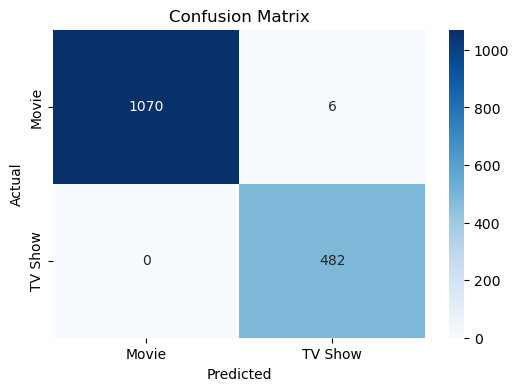

In [355]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### NAIVE - BAYES (Bernoulli) :

In [356]:
from sklearn.naive_bayes import BernoulliNB

prediction_pipeline_2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BernoulliNB(
    alpha=1.0,
    binarize=0.0,
    fit_prior=True,
    class_prior=None
))
])


prediction_pipeline_2.fit(X_train, y_train)


y_pred = prediction_pipeline_2.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model (similar to laptop project)
with open('netflix_type_predictor_pipeline_2.pkl', 'wb') as f:
    pickle.dump(prediction_pipeline_2, f)

Accuracy: 0.8954

Classification Report:
              precision    recall  f1-score   support

       Movie       0.98      0.86      0.92      1076
     TV Show       0.76      0.96      0.85       482

    accuracy                           0.90      1558
   macro avg       0.87      0.91      0.89      1558
weighted avg       0.91      0.90      0.90      1558


Confusion Matrix:
[[930 146]
 [ 17 465]]


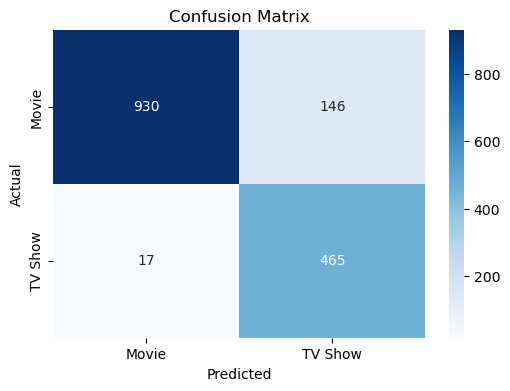

In [357]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### KNN:

In [358]:
from sklearn.neighbors import KNeighborsClassifier

prediction_pipeline_3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        algorithm='auto',
        metric='minkowski',
        p=2
    ))
])

prediction_pipeline_3.fit(X_train, y_train)

y_pred = prediction_pipeline_3.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model
with open('netflix_type_predictor_knn_pipeline_3.pkl', 'wb') as f:
    pickle.dump(prediction_pipeline_3, f)

Accuracy: 0.9891

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      0.99      0.99      1076
     TV Show       0.97      1.00      0.98       482

    accuracy                           0.99      1558
   macro avg       0.98      0.99      0.99      1558
weighted avg       0.99      0.99      0.99      1558


Confusion Matrix:
[[1060   16]
 [   1  481]]


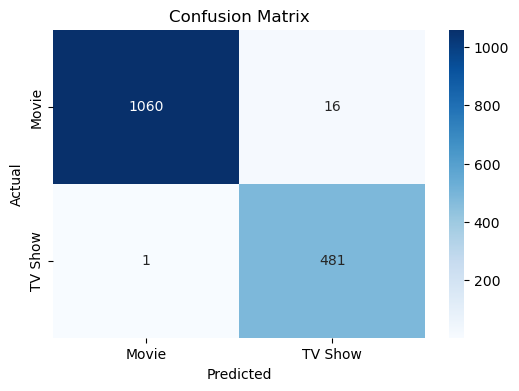

In [359]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **CONCLUSION:** Highest accuracy is acheived through Logistic Regression.

## Q2] Predict whether a piece of content is a Movie or a TV Show based on features like cast-size, country, and release trends?

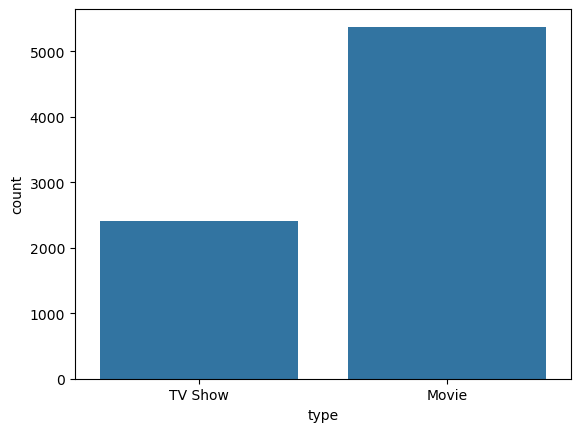

In [360]:
sns.countplot(x=df["type"])
plt.show()

In [361]:
data = df.groupby("type")["genre_count"].sum().reset_index()
data

,type,genre_count
0,Movie,11546
1,TV Show,5525


In [362]:
data = df.groupby("type")["cast_count"].sum().reset_index()
data

,type,cast_count
0,Movie,38738
1,TV Show,17935


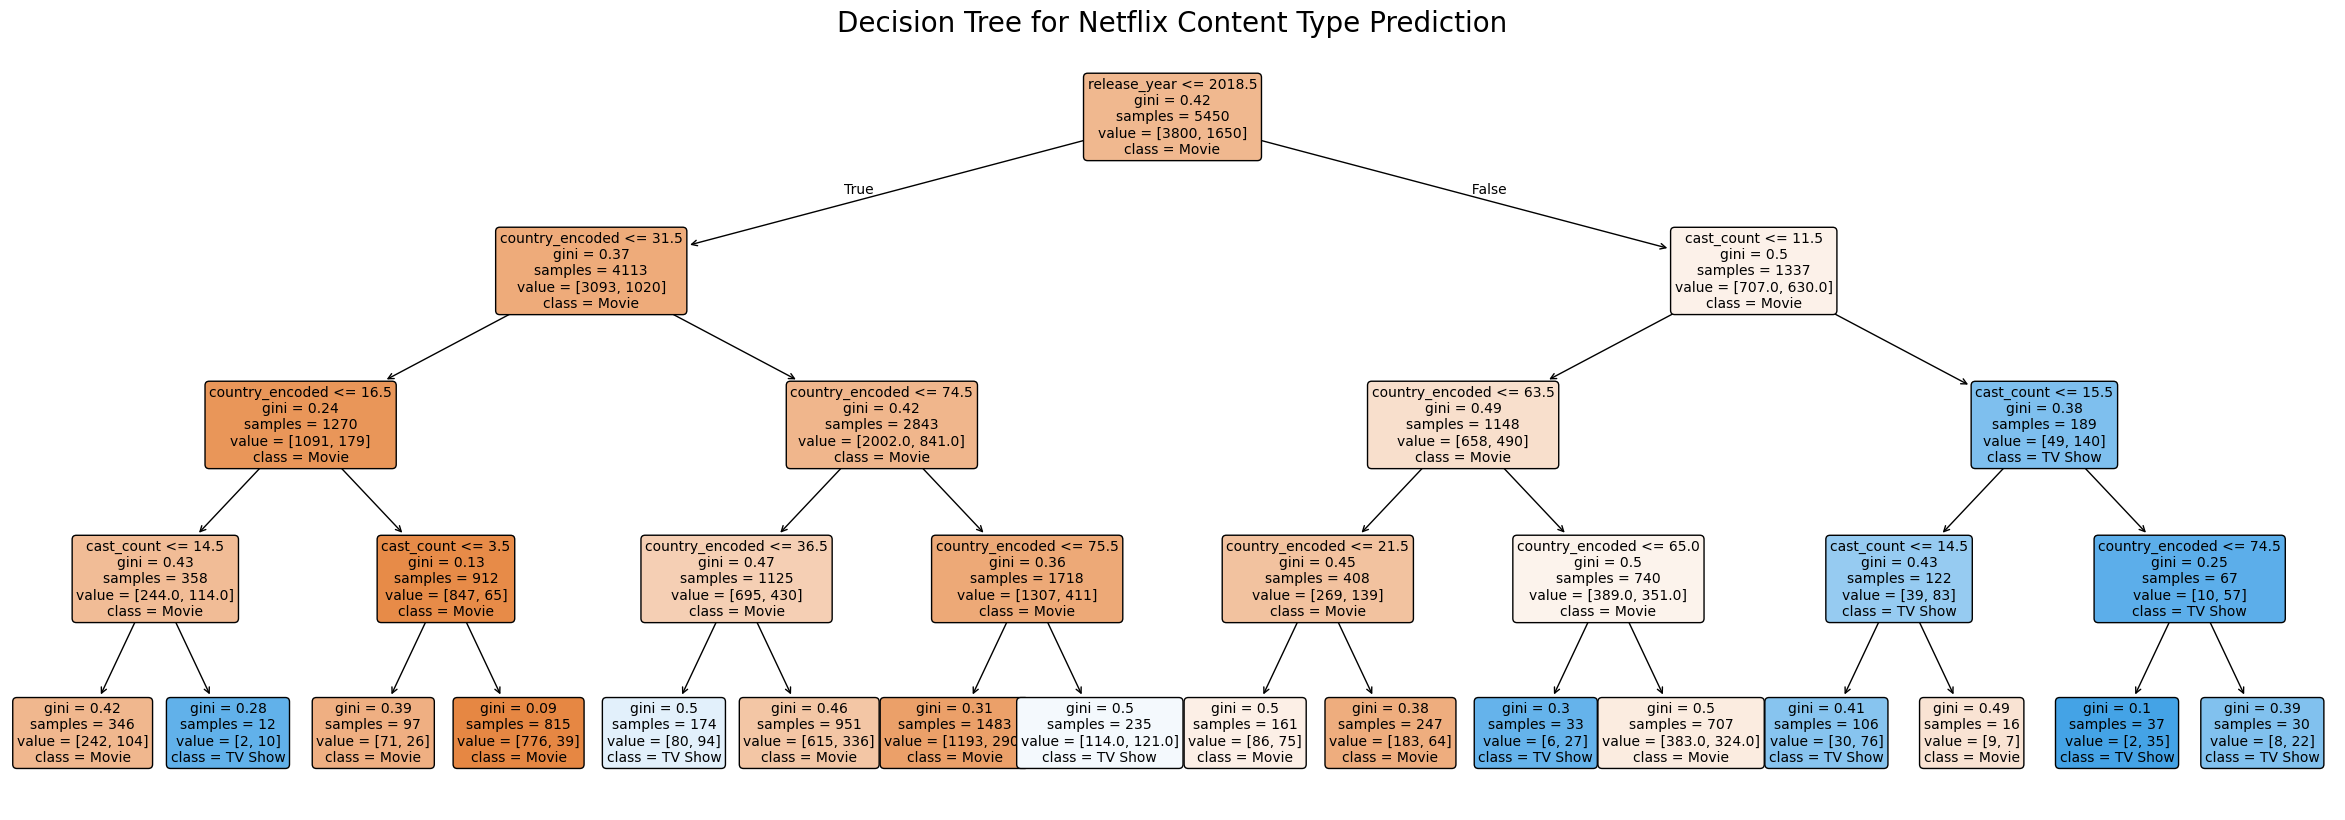

Accuracy: 0.7064612751390672


In [363]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Preprocessing categorical features
# We extract the first country and first genre to simplify the categories
df['first_country'] = df['country'].fillna('Unknown').apply (lambda x: x.split(',')[0])

# 2. Encode strings to numbers
le_country = LabelEncoder()

df['country_encoded'] = le_country.fit_transform(df['first_country'])



feature_cols = ["cast_count", "country_encoded", "release_year"]
X = df[feature_cols]
y = df["type"]


X_train , X_test , y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=42)


model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train , y_train)


plt.figure(figsize=(30,10))
plot_tree(model, 
          feature_names=feature_cols, 
          class_names=["Movie", "TV Show"], 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          precision=2)

plt.title("Decision Tree for Netflix Content Type Prediction", fontsize=20)
plt.show()


print("Accuracy:",model.score(X_test, y_test))

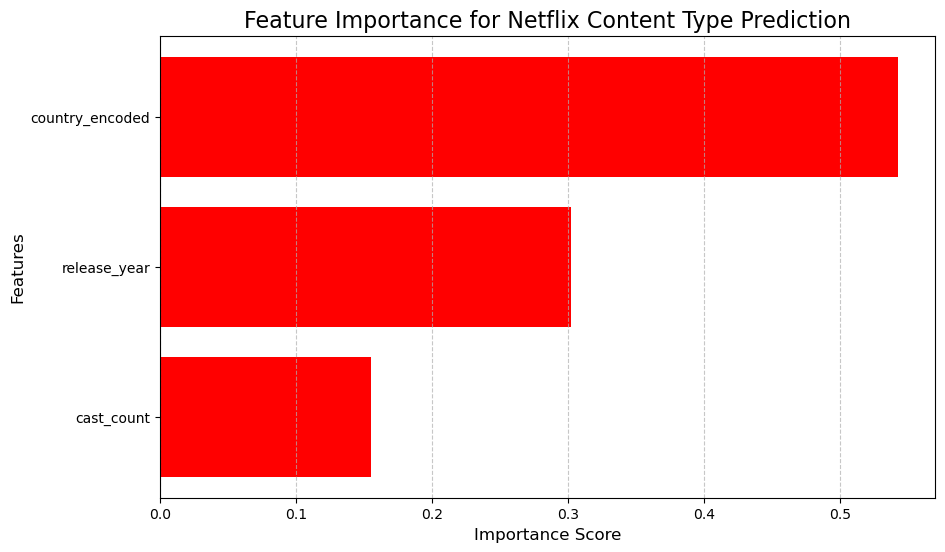

,index,Feature,Importance
0,0,country_encoded,0.542345
1,1,release_year,0.302328
2,2,cast_count,0.155326


In [364]:


# 1. Create a DataFrame to hold the feature names and their corresponding importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 2. Plot the Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='red')

plt.title('Feature Importance for Netflix Content Type Prediction', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# 3. Print the values for reference
# Create the sorted dataframe and drop the old index
importance_display = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the clean table
importance_display.reset_index()

## Q3] Which countries dominate Netflix content, and how does the Movie vs TV-Show ratio change across the top 10 countries?

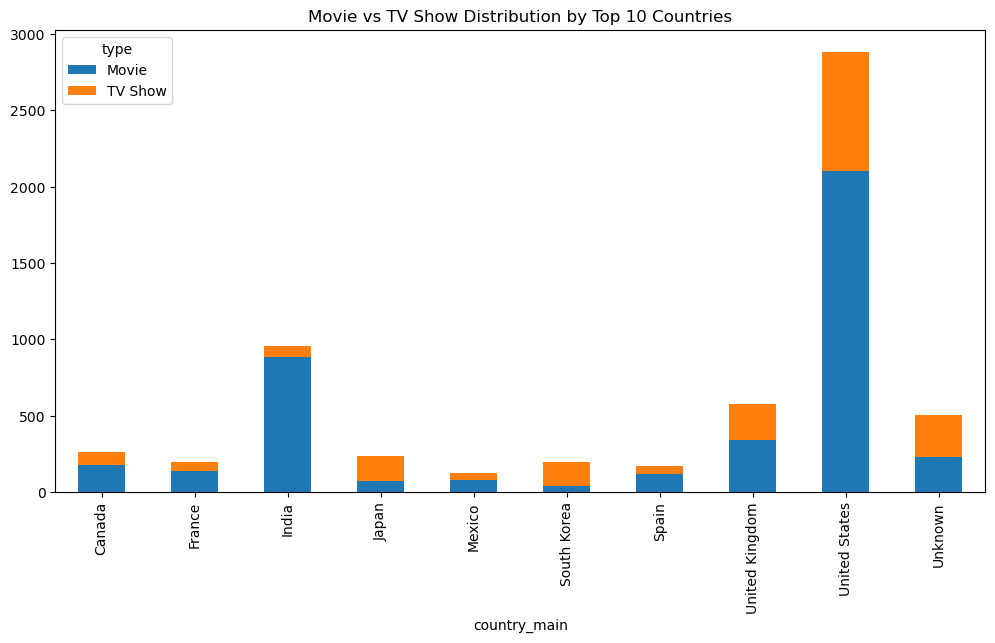

In [365]:
top10_countries = df['country_main'].value_counts().head(10).index
country_type = df[df['country_main'].isin(top10_countries)].groupby(['country_main', 'type']).size().unstack()
country_type.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Movie vs TV Show Distribution by Top 10 Countries')
plt.show()

## Q4] Do titles with a known director have significantly higher cast_count, genre_count, or longer duration than “Unknown” director titles?

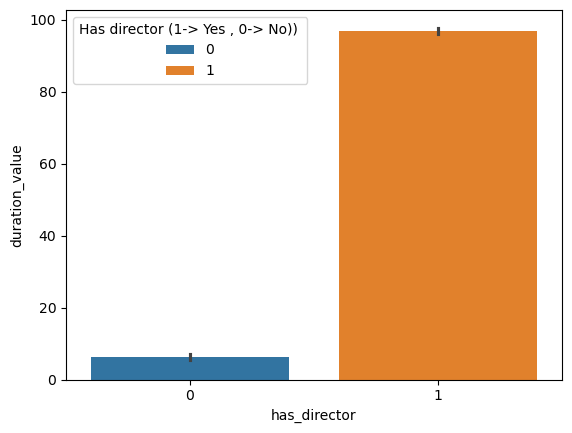

In [366]:
df.groupby('has_director')[['cast_count', 'genre_count', 'duration_value']].mean().round(2)
sns.barplot(x='has_director', y='duration_value',hue="has_director", data=df)
plt.legend(title="Has director (1-> Yes , 0-> No)) ")
plt.show()

In [367]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,month_added,cast_count,genre_count,duration_type,country_main,rating_category,has_director,first_country,country_encoded
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,11,3,TV Show,Brazil,Adult,0,Brazil,6
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,8,3,Movie,India,Adult,1,India,28
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,4,3,Movie,Indonesia,Kids,1,Indonesia,29
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,11,1,Movie,United States,Adult,1,United States,75
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,12,1,3,TV Show,United Kingdom,Kids,0,United Kingdom,74


### CONTENT- RECOMMENDATION SYSTEM:

In [368]:
import pandas as pd
import pickle
import numpy as np

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# STEP 1: Create tags (same as before)
# -----------------------------
df['tags'] = (
    df['title'].fillna('') + " " +
    df['genres'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['cast'].fillna('') + " " +
    df['director'].fillna('') + " " +
    df['country_main'].fillna('') + " " +
    df['rating_category'].fillna('') + " " +
    df['type'].fillna('')
)

df['tags'] = df['tags'].str.lower()

# -----------------------------
# STEP 2: Tokenization
# -----------------------------
df['tokens'] = df['tags'].apply(lambda x: word_tokenize(x))

# -----------------------------
# STEP 3: Train Word2Vec Model
# -----------------------------
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

# -----------------------------
# STEP 4: Convert each content into vector
# -----------------------------
def get_doc_vector(tokens):
    vectors = []
    for word in tokens:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(100)
    
    return np.mean(vectors, axis=0)

df['vector'] = df['tokens'].apply(get_doc_vector)

# Convert to matrix
vectors = np.vstack(df['vector'].values)

# -----------------------------
# STEP 5: Recommendation Class
# -----------------------------
class RecommendationModel:
    def __init__(self, vectors, df, w2v_model):
        self.vectors = vectors
        self.df = df.reset_index(drop=True)
        self.w2v_model = w2v_model

    def text_to_vector(self, text):
        tokens = word_tokenize(text.lower())
        return get_doc_vector(tokens)

    def recommend(self, content, top_n=10):
        mask = self.df['title'].str.contains(content, case=False, na=False)
        
        if mask.any():
            idx = self.df[mask].index[0]
            query_vec = self.vectors[idx].reshape(1, -1)
            print(" Found exact title → using full features")
        else:
            query_vec = self.text_to_vector(content).reshape(1, -1)

        similarity = cosine_similarity(query_vec, self.vectors)[0]

        content_list = sorted(
            list(enumerate(similarity)),
            reverse=True,
            key=lambda x: x[1]
        )[1:top_n+1]

        print(f"\n\nRecommendations similar to: **{content}**\n")

        for rank, (i, score) in enumerate(content_list, 1):
            row = self.df.iloc[i]
            print(f"{rank:2}) • {row['title']}  "
                  f"| {row['type']}  "
                  f"| {row['genres'][:70]}...")

# -----------------------------
# STEP 6: Save & Load Model
# -----------------------------
model = RecommendationModel(vectors, df, w2v_model)

with open("content_recommendation_word2vec.pkl", "wb") as f:
    pickle.dump(model, f)

with open("content_recommendation_word2vec.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# -----------------------------
# STEP 7: Test
# -----------------------------
loaded_model.recommend("Kesari 2")
loaded_model.recommend("Dune")
loaded_model.recommend("Stranger Things")
loaded_model.recommend("Article 15")
loaded_model.recommend("Raone")
loaded_model.recommend("3 Idiots")
loaded_model.recommend("Dhurandhar")
loaded_model.recommend("Dhurandhar - The Revenge")



Recommendations similar to: **Kesari 2**

 1) • Untamed Romania  | Movie  | Children & Family Movies, Documentaries, International Movies...
 2) • Magnus  | Movie  | Children & Family Movies, Documentaries, International Movies...
 3) • This Was Tomorrow  | Movie  | Documentaries, International Movies, Music & Musicals...
 4) • Spelling the Dream  | Movie  | Children & Family Movies, Documentaries...
 5) • Vettai  | Movie  | Action & Adventure, International Movies, Music & Musicals...
 6) • Covered: Alive in Asia  | Movie  | Documentaries, Faith & Spirituality, Music & Musicals...
 7) • Sky Tour: The Movie  | Movie  | Documentaries, International Movies, Music & Musicals...
 8) • Luccas Neto in: Children's Day  | Movie  | Children & Family Movies, Comedies, Music & Musicals...
 9) • Roots  | Movie  | Documentaries, International Movies, Music & Musicals...
10) • Beat Bugs: All Together Now  | Movie  | Children & Family Movies, Music & Musicals...


Recommendations similar to: **Dune

### Q5] Can we forecast how many titles Netflix will add in 2022–2025?

In [369]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

yearly_data = df.groupby('year_added').size().reset_index(name='title_count')
yearly_data = yearly_data[yearly_data['year_added'] <= 2021]

X = yearly_data[['year_added']]
y = yearly_data['title_count']

# ✅ DO THIS ONLY ONCE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

future_years = np.array([[2022], [2023], [2024], [2025]])

### a) Linear Regression:

In [370]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=1)),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)
linear_forecast = linear_pipeline.predict(future_years)

### b) Adaboost:

In [371]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada_pipeline = Pipeline([
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])

ada_pipeline.fit(X_train, y_train)

y_pred_ada = ada_pipeline.predict(X_test)
ada_forecast = ada_pipeline.predict(future_years)

### c) Decision tree:

In [372]:
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline([
    ('model', DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)
tree_forecast = tree_pipeline.predict(future_years)

### d) Extratrees:

In [373]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error


et_pipeline = Pipeline([
    ('model', ExtraTreesRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

et_pipeline.fit(X_train, y_train)

y_pred_et = et_pipeline.predict(X_test)
et_forecast = et_pipeline.predict(future_years)


In [374]:
forecast_df = pd.DataFrame({
    'Year': [2022, 2023, 2024, 2025],
    'Linear': linear_forecast.astype(int),
    'AdaBoost': ada_forecast.astype(int),
    'Decision Tree': tree_forecast.astype(int),
    'Extra Trees': et_forecast.astype(int)
})

print(forecast_df)


print("\n\n\n")

results = pd.DataFrame({
    'Model': ['Linear', 'AdaBoost', 'Decision Tree','Extra Trees'],
    'R2 Score': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ada),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test,y_pred_et)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ada),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_et)
    ]
})

print(results)

   Year  Linear  AdaBoost  Decision Tree  Extra Trees
0  2022    1283       117            117          136
1  2023    1400       117            117          136
2  2024    1517       117            117          136
3  2025    1634       117            117          136




           Model  R2 Score         MAE
0         Linear  0.186415  701.208477
1       AdaBoost  0.643207  418.583333
2  Decision Tree  0.643199  419.055556
3    Extra Trees  0.918907  201.677222


### CONCLUSION] Tree-based models such as DecisionTreeRegressor , Extratrees and AdaBoostRegressor were tested but produced similar and unrealistic forecasts. This is because tree-based models do not extrapolate beyond the training data and tend to create step-like predictions, making them unsuitable for time-series forecasting tasks with limited features.

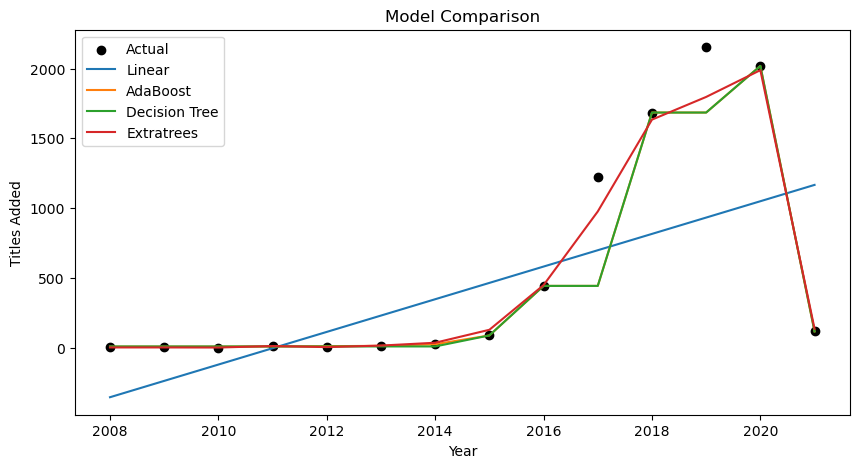

In [375]:
# Sort for smooth plotting
sorted_idx = X['year_added'].argsort()
X_sorted = X.iloc[sorted_idx]

plt.figure(figsize=(10,5))

plt.scatter(X, y, color='black', label='Actual')

plt.plot(X_sorted, linear_pipeline.predict(X_sorted), label='Linear')
plt.plot(X_sorted, ada_pipeline.predict(X_sorted), label='AdaBoost')
plt.plot(X_sorted, tree_pipeline.predict(X_sorted), label='Decision Tree')
plt.plot(X_sorted, et_pipeline.predict(X_sorted), label='Extratrees')


plt.legend()
plt.title('Model Comparison')
plt.xlabel('Year')
plt.ylabel('Titles Added')

plt.show()

### CONCLUSION] Linear regression performed best for trend modeling, while tree-based models failed to extrapolate future values due to their step-wise nature.

## Q6] How is Netflix content growing over time?

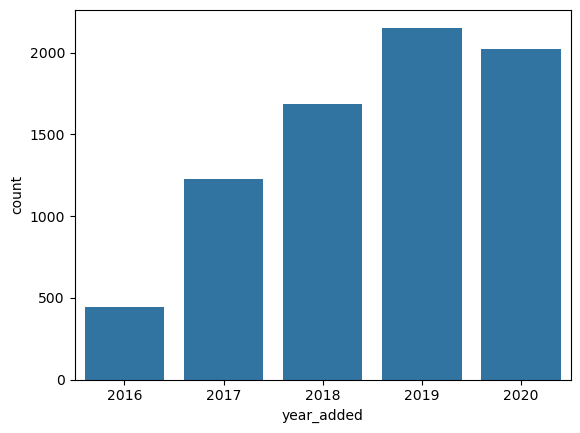

In [376]:
data = df["year_added"].value_counts().reset_index()
data = data.head(5)
sns.barplot(x=data["year_added"],y=data["count"])
plt.show()

In [377]:
yearly_data.sort_values(by="title_count",ascending=False).head(5)

,year_added,title_count
11,2019,2153
12,2020,2019
10,2018,1685
9,2017,1225
8,2016,443


### CONCLUSION] Netflix content has shown a consistent upward trend over the years, with significant growth in recent years. Linear models were able to capture this trend effectively, while tree-based models failed due to their inability to extrapolate beyond training data. This highlights the importance of selecting models based on problem type rather than complexity.

## Q7] Who are the top contributing directors?

In [378]:
data = df["director"].value_counts().reset_index().head()
data = data[data["director"]!="Unknown"]
data

,director,count
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Jay Karas,14
4,Cathy Garcia-Molina,13


### CONCLUSION] The top contributing directors include:
1) Raúl Campos
2) Jan Suter
3) Marcus Raboy
4) Jay Karas
5) Cathy Garcia-Molina


## Q8] Which countries contribute most to the content-library?

In [379]:
data = df["first_country"].value_counts().reset_index().head()
data = data[data["first_country"]!="Unknown"]
data

,first_country,count
0,United States,2883
1,India,956
2,United Kingdom,577
4,Canada,259


### CONCLUSION] The top contributing countries are:
1) United States
2) India
3) United Kingdom
4) Canada

## Q9] Is there a statistically significant difference in the average duration of Netflix content between Movies and TV Shows?

In [380]:

from scipy.stats import ttest_ind


# Split data into two groups
movies = df[df['type'] == 'Movie']['duration_value']
tv_shows = df[df['type'] == 'TV Show']['duration_value']

# Perform Independent T-Test
t_stat, p_value = ttest_ind(movies, tv_shows, equal_var=False)

# Print results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("There is a statistically significant difference in duration.")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("No significant difference in duration.")

T-Statistic: 249.79900942857398
P-Value: 0.0

Reject Null Hypothesis (H0)
There is a statistically significant difference in duration.


### CONCLUSION] There is a significant difference in the durations of tv-shows and movies.

## Q10] Can Netflix content be grouped into meaningful clusters based on features like genre, cast size, and duration?

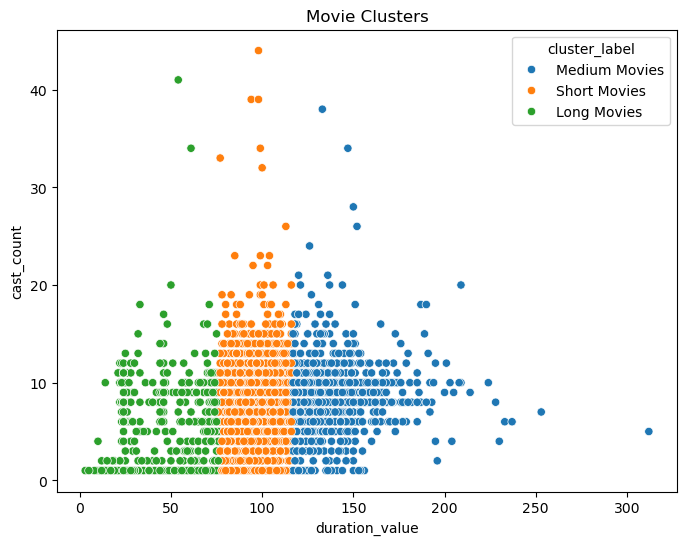

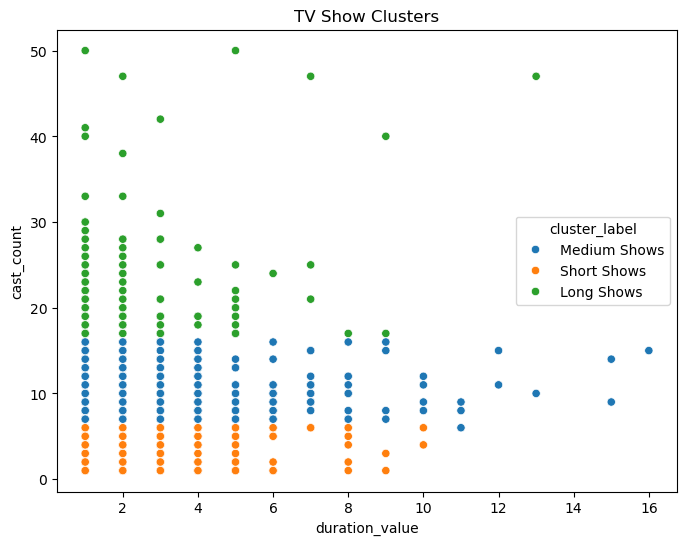

In [381]:
from sklearn.cluster import KMeans



movies_df = df[df['type'] == 'Movie'].copy()
tv_df = df[df['type'] == 'TV Show'].copy()


features = ['duration_value', 'cast_count', 'genre_count']






kmeans_movies = KMeans(n_clusters=3, random_state=42)
movies_df['cluster'] = kmeans_movies.fit_predict(movies_df[features])

movie_labels = {
    0: "Short Movies",
    1: "Medium Movies",
    2: "Long Movies"
}
movies_df['cluster_label'] = movies_df['cluster'].map(movie_labels)







kmeans_tv = KMeans(n_clusters=3, random_state=42)
tv_df['cluster'] = kmeans_tv.fit_predict(tv_df[features])

tv_labels = {
    0: "Short Shows",
    1: "Medium Shows",
    2: "Long Shows"
}
tv_df['cluster_label'] = tv_df['cluster'].map(tv_labels)









# Movies Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='duration_value',
    y='cast_count',
    hue='cluster_label',
    data=movies_df
)
plt.title("Movie Clusters")
plt.show()

# TV Shows Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='duration_value',
    y='cast_count',
    hue='cluster_label',
    data=tv_df
)
plt.title("TV Show Clusters")
plt.show()

In [382]:
print("\n--- MOVIE CLUSTERS ---")
for label in movies_df['cluster_label'].unique():
    subset = movies_df[movies_df['cluster_label'] == label]
    print(label)
    print("Avg Duration:", subset['duration_value'].mean())
    print("Avg Cast:", subset['cast_count'].mean())

print("\n--- TV SHOW CLUSTERS ---")
for label in tv_df['cluster_label'].unique():
    subset = tv_df[tv_df['cluster_label'] == label]
    print(label)
    print("Avg Duration:", subset['duration_value'].mean())
    print("Avg Cast:", subset['cast_count'].mean())


--- MOVIE CLUSTERS ---
Medium Movies
Avg Duration: 136.6070549630845
Avg Cast: 8.71862182116489
Short Movies
Avg Duration: 96.86318332829961
Avg Cast: 7.569918453639384
Long Movies
Avg Duration: 55.184179456906726
Avg Cast: 3.5962219598583234

--- TV SHOW CLUSTERS ---
Medium Shows
Avg Duration: 1.9271012006861064
Avg Cast: 10.01114922813036
Short Shows
Avg Duration: 1.5527502254283139
Avg Cast: 2.8872858431018935
Long Shows
Avg Duration: 2.303703703703704
Avg Cast: 22.666666666666668


### CONCLUSION] Netflix Content Clustering Analysis (Improved)

Using K-Means clustering, Netflix content was analyzed **separately for Movies and TV Shows**, resulting in more meaningful and realistic clusters based on duration, cast size, and genre count.

Instead of mixing both content types, clustering was performed independently to account for their fundamental differences (e.g., movie duration in minutes vs TV shows in seasons). This significantly improved the quality and interpretability of clusters.

For both categories, content was grouped into three clusters:

- **Movies** → Short Movies, Medium Movies, Long Movies  
- **TV Shows** → Short Shows, Medium Shows, Long Shows  

The analysis revealed that **duration remains the most influential feature** in both cases, as clusters are primarily separated along the duration axis.

#### 🔹 Key Observations:

- **Short Movies / Shows**: Lower duration with relatively smaller or average cast sizes  
- **Medium Movies / Shows**: Balanced duration and moderate cast involvement  
- **Long Movies / Shows**: Higher duration with slightly larger or comparable cast sizes  

This separation ensures that clustering reflects **true consumption patterns** rather than distorted groupings caused by mixing fundamentally different formats.

---

### 🚀 Business Insight (Stronger Version)

This refined clustering approach provides deeper and more actionable insights:

- Enables Netflix to **design strategies separately for Movies and TV Shows**
- Helps in **personalized recommendations** based on content length preferences within each category  
- Supports better **content investment decisions** (e.g., short-form vs long-form movies vs binge-worthy series)  
- Improves understanding of **viewer engagement patterns across formats**

👉 Overall, separating clustering by content type leads to **more accurate segmentation and better business decisions** compared to a combined approach.

### PROJECT BY:
- **Name:** Om Satyawan Pathak
- **Email:** omsatyawanpathakwebdevelopment@gmail.com
- **Linkedin:** www.linkedin.com/in/om-satyawan-pathak-029b02368